In [4]:
import jupyter_utils as ju
import straindesign as sd
import numpy as np
import matplotlib as plt


In [1]:
#base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" / "11.09_Models"
#model = ju.load_model(base_dir,"Experiment", "250723_iABA974_BLG.sbml")
base_dir = Path.home() / "Documents" / "PhD" / "SOF1-GEM"
#base_dir = Path.home() / "Documents" / "PhD" / "SOF1-GEM" 
model = ju.load_model(base_dir,"Models", "250808_iABA974.sbml")

In [8]:
model1.objective = "EX_BLG_x1_e"
model1.optimize()
model1.reactions.get_by_id('Growth').bounds = 0.0, 0.0
# model1.reactions.get_by_id('EX_h2_e').bounds = -50.0, 1000.0
# model1.reactions.get_by_id('EX_o2_e').bounds = -100.0, 1000.0
model1.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,2.39,1,100.00%
h2_e,EX_h2_e,19.4,0,0.00%
nh4_e,EX_nh4_e,0.6285,0,0.00%
o2_e,EX_o2_e,7.336,0,0.00%
so4_e,EX_so4_e,0.01236,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
BLG_x1_e,EX_BLG_x1_e,-0.4822,0,0.00%
h2o_e,EX_h2o_e,-18.33,0,0.00%


In [30]:
ju.print_reaction_details(model1,"BLG_x1_production")
ju.print_reaction_details(model,"BLG_x1_production")


Reaction ID   : BLG_x1_production
Name          : 
Equation      : 0.0811965811965812 ala__L_c + 0.0384615384615385 arg__L_c + 0.00854700854700855 asn__L_c + 0.047008547008547 asp__L_c + 0.0128205128205128 cys__L_c + 0.0641025641025641 gln__L_c + 0.0555555555555556 glu__L_c + 0.094017094017094 gly_c + 0.0299145299145299 his__L_c + 0.0213675213675214 ile__L_c + 0.158119658119658 leu__L_c + 0.0256410256410256 lys__L_c + 0.0128205128205128 met__L_c + 0.0341880341880342 phe__L_c + 0.0683760683760684 pro__L_c + 0.0726495726495727 ser__L_c + 0.047008547008547 thr__L_c + 0.0299145299145299 trp__L_c + 0.0213675213675214 tyr__L_c + 0.0769230769230769 val__L_c --> BLG_x1_c
Lower Bound   : 0.0
Upper Bound   : 1000.0

Metabolites and Stoichiometry:
 - his__L_c       : -0.0299145299145299  Name: L-Histidine                                        Charge:   0  Formula: C6H9N3O2
 - pro__L_c       : -0.0683760683760684  Name: L-Proline                                          Charge:   0  Formula: C5H

This notebook will mainly use the strain design toolbox

## production envelope

Production envelopes project the solution space of steady-state flux vectors onto the dimensions of growth rate and product synthesis rate. 

In [2]:
model.reactions.get_by_id("ATPM").bounds = 0.0 ,0.0

In [ ]:
sd.plot_flux_space(model,('-EX_co2_e','-EX_o2_e'))

Production envelope with modified ATPM

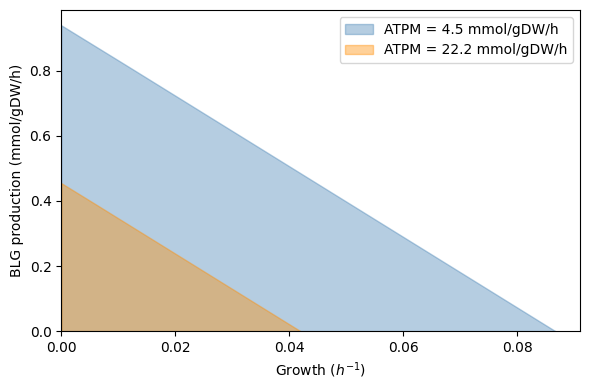

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def production_envelope(model1, biomass_rxn, product_rxn, atpm_value, color, label):
    # Set ATP maintenance
    model1.reactions.get_by_id('ATPM').bounds = (atpm_value, 1000.0)

    # Optimize for biomass to get max growth
    model1.objective = biomass_rxn
    sol = model1.optimize()

    growth_rates = np.linspace(0, sol.fluxes[biomass_rxn], 50)
    product_fluxes = []

    for gr in growth_rates:
        with model1:
            # Fix growth rate
            model1.reactions.get_by_id(biomass_rxn).lower_bound = gr
            model1.reactions.get_by_id(biomass_rxn).upper_bound = gr

            # Maximize product
            model1.objective = product_rxn
            sol = model1.optimize()
            product_fluxes.append(sol.objective_value if sol.status == 'optimal' else 0)

    # Plot
    plt.fill_between(growth_rates, product_fluxes, color=color, alpha=0.4, label=label)


# Define reactions
biomass_rxn = "Growth"
product_rxn = "EX_BLG_x1_e"

# Plot envelopes for two ATPM values
plt.figure(figsize=(6,4))
production_envelope(model1, biomass_rxn, product_rxn, atpm_value=4.5, color="steelblue", label="ATPM = 4.5 mmol/gDW/h")
production_envelope(model1, biomass_rxn, product_rxn, atpm_value=22.2, color="darkorange", label="ATPM = 22.2 mmol/gDW/h")

plt.xlabel('Growth ($h^{-1}$)')
plt.ylabel(f'BLG production (mmol/gDW/h)')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

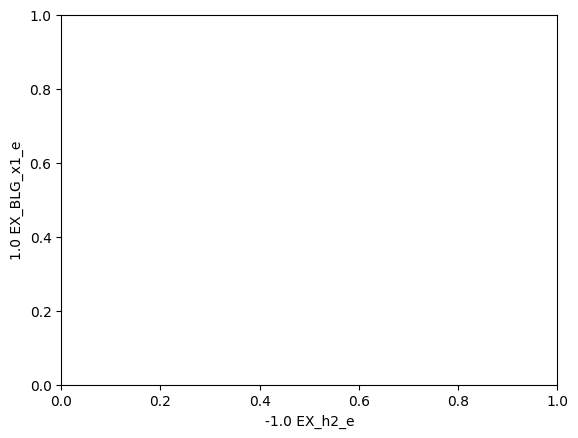

In [31]:
model1 = model.copy()
model1.reactions.get_by_id('ATPM').bounds = 4.5, 1000.0
sd.plot_flux_space(model1,('-EX_h2_e','EX_BLG_x1_e'))

## 3D plots


A 3-dimensional plot may help tp reveal more complex relationships between fluxes and yields. In the following plot, we analyze the relationship between oxygen uptake, growth rate and ethanol yield.

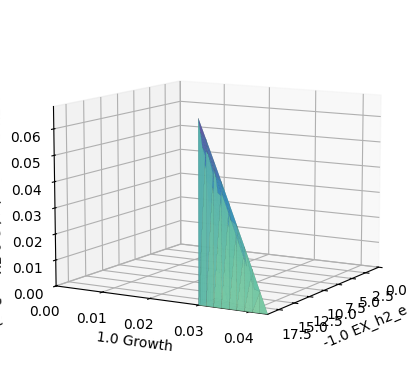

In [18]:
sd.plot_flux_space(model,('-EX_h2_e','Growth',('EX_BLG_x1_e','-EX_co2_e')),points=10);

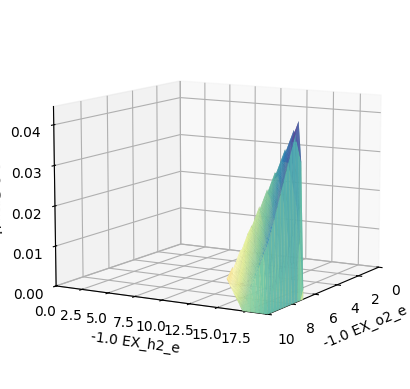

In [7]:
sd.plot_flux_space(model,('-EX_o2_e','-EX_h2_e','Growth'),
                   constraints='-EX_o2_e <= 10',points=20);

In [13]:
ju.print_reaction_details(model, 'EX_h2_e')
#sd.plot_flux_space(model,('Growth',('Growth','-EX_co2_e')))



Reaction ID   : EX_h2_e
Name          : EX_h2_e
Equation      : h2_e <-- 
Lower Bound   : -19.4
Upper Bound   : 0.0

Metabolites and Stoichiometry:
 - h2_e           :   -1.0  Name: Hydrogen                                           Charge:   0  Formula: H2

Sum of Charge Balance: 0.0

Associated Genes:
 - None


In [4]:
from cameo import phenotypic_phase_plane

In [22]:
result = phenotypic_phase_plane(model,
                                variables=[model.reactions.EX_h2_e,model.reactions.EX_o2_e],
                                objective=model.reactions.Growth,
                                points=10)

In [23]:
result.data_frame

,EX_h2_e,EX_o2_e,objective_lower_bound,objective_upper_bound,c_yield_lower_bound,c_yield_upper_bound,mass_yield_lower_bound,mass_yield_upper_bound
0,-19.4,-11.552632,6.950574e-14,-7.111358e-15,NaN,23.817147,NaN,NaN
1,-19.4,-10.857895,4.300988e-16,7.464868e-03,NaN,9.374136,NaN,NaN
2,-19.4,-10.163158,-2.626243e-15,1.492974e-02,1.701954e-12,9.374136,NaN,NaN
3,-19.4,-9.468421,1.462398e-29,2.239460e-02,7.072593e-27,9.374136,NaN,NaN
4,-19.4,-8.773684,-7.721867e-30,2.985947e-02,2.502104e-27,9.374136,NaN,NaN
...,...,...,...,...,...,...,...,...
95,-10.6,-8.078947,NaN,NaN,NaN,NaN,NaN,NaN
96,-10.6,-7.384211,NaN,NaN,NaN,NaN,NaN,NaN
97,-10.6,-6.689474,NaN,NaN,NaN,NaN,NaN,NaN
98,-10.6,-5.994737,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
result.plot()

TypeError: plot() missing 1 required positional argument: 'plotter'